In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

import cmcrameri.cm as cmc



In [6]:
data_path = "/Volumes/VPB_external/Docs/UIUC/Beckman/Visualization_Workshop/data/jingdan/conf_evolution_data"
structures = ["HT_HT_RR", "HT_HT_RR_H5T", "HT_HT_RR_H5T_TS"]

In [7]:

def plot_evolution(structure, save_path=""):
    # 1. Load the data
    df = pd.read_csv(f'{data_path}/{structure}.csv', index_col=0)

    # 2. Define stages and setup X-axis coordinates
    n_notNAN_each_stage = df.notna().sum(axis=0)
    # print(n_notNAN_each_stage)
    stages = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']
    x_orig = np.arange(1, len(stages) + 1)  # [1, 2, 3, 4, 5]
    x_smooth = np.linspace(x_orig.min(), x_orig.max(), 500)

    fig, ax = plt.subplots(figsize=(12, 8))

    # 3. Define a GLOBAL Color Gradient
    # To show color changes accurately across stages, we need the min/max of ALL stages, 
    # not just Stage 5.
    all_energies = df[stages].values.flatten()
    finite_energies = all_energies[np.isfinite(all_energies)]

    if len(finite_energies) > 0:
        norm = Normalize(vmin=finite_energies.min(), vmax=finite_energies.max())
    else:
        norm = Normalize(vmin=0, vmax=1)

    try:
        cmap = plt.colormaps['coolwarm']
    except AttributeError:
        cmap = plt.get_cmap('coolwarm')

    # 4. Find the top n conformers
    top_n = 20
    df_sorted = df.sort_values(by='Stage 5')
    top_conformers = df_sorted.head(top_n).index

    # 5. Plot each conformer's evolution
    for index, row in df.iterrows():
        y_orig = row[stages].values.astype(float)
        if not np.all(np.isfinite(y_orig)): continue

        interpolator = PchipInterpolator(x_orig, y_orig)
        y_smooth = interpolator(x_smooth)

        if index in top_conformers:
            # Highlight it with a continuous gradient using LineCollection
            # We chop the line into tiny (x,y) to (x+1, y+1) segments
            points = np.array([x_smooth, y_smooth]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Create the collection of segments
            lc = LineCollection(segments, cmap=cmap, norm=norm)
            # Set the color of each segment based on its specific y_smooth value
            lc.set_array(y_smooth[:-1])
            lc.set_linewidth(3)
            lc.set_alpha(0.9)
            lc.set_zorder(4)

            ax.add_collection(lc) # Add the gradient line to the plot
            
            # Plot the actual data points at each stage, colored by their specific energy
            scatter_colors = cmap(norm(y_orig))
            ax.scatter(x_orig, y_orig, color=scatter_colors, s=50, zorder=5, edgecolor='black', linewidth=0.5)
            
        else:
            # Background it! Make it faint grey
            ax.plot(x_smooth, y_smooth, color='lightgray', alpha=0.15, linewidth=1, zorder=2)

    # 6. Styling the Graph
    for x in x_orig:
        ax.axvline(x, color='gray', linestyle='--', alpha=0.3, zorder=1)

    ax.set_xticks(x_orig)
    ax.set_xticklabels([f"{stage} ({n_notNAN_each_stage.iloc[i]})" for i, stage in enumerate(stages)], fontsize=12, fontweight='bold')
    ax.set_ylabel('Relative Energy (kcal/mol)', fontsize=12, fontweight='bold')
    ax.set_title('Top Conformer Energy Evolution Across DFT Stages', fontsize=14, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add a colorbar to explain the gradient
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Relative Energy at specific stage (kcal/mol)', rotation=270, labelpad=15)

    # Ensure matplotlib scales the axes correctly when using LineCollections
    ax.autoscale() 
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

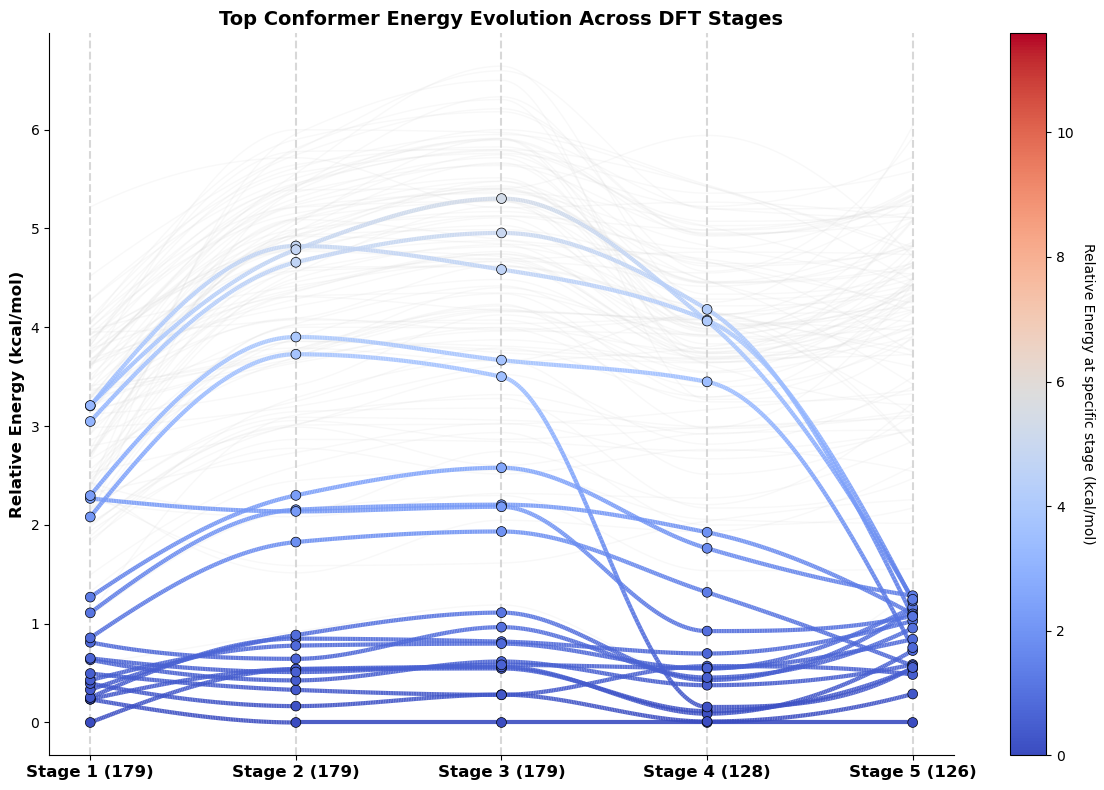

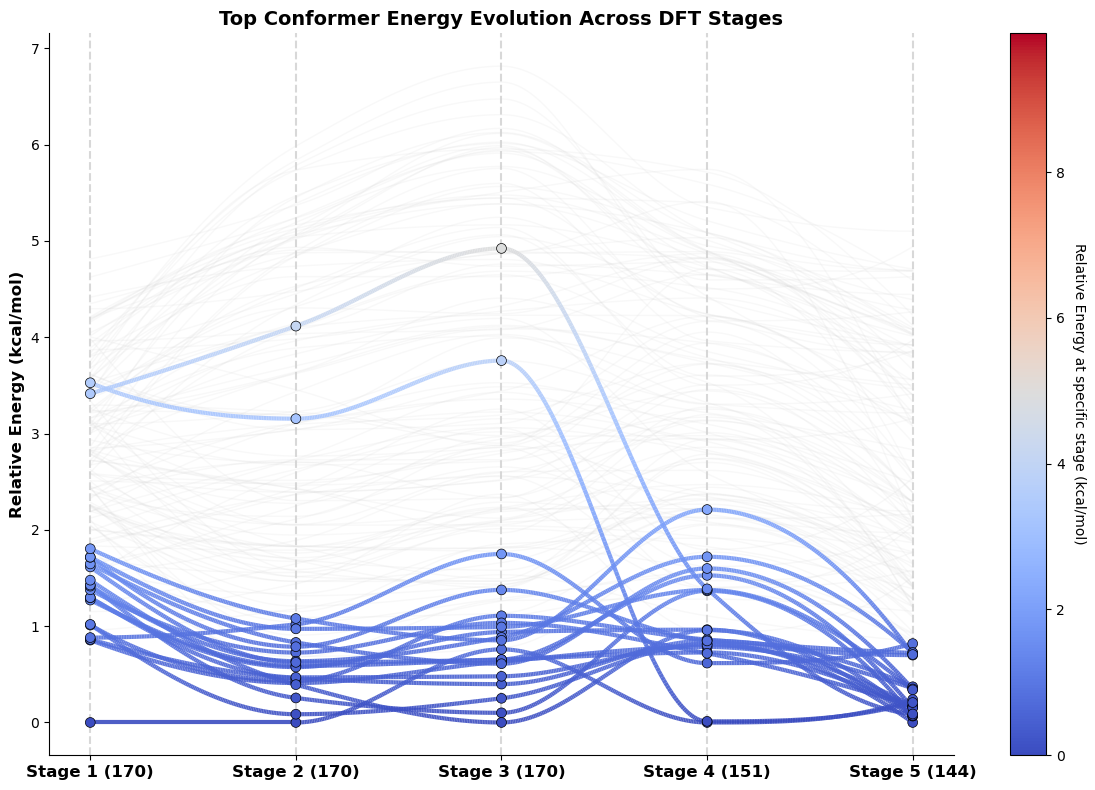

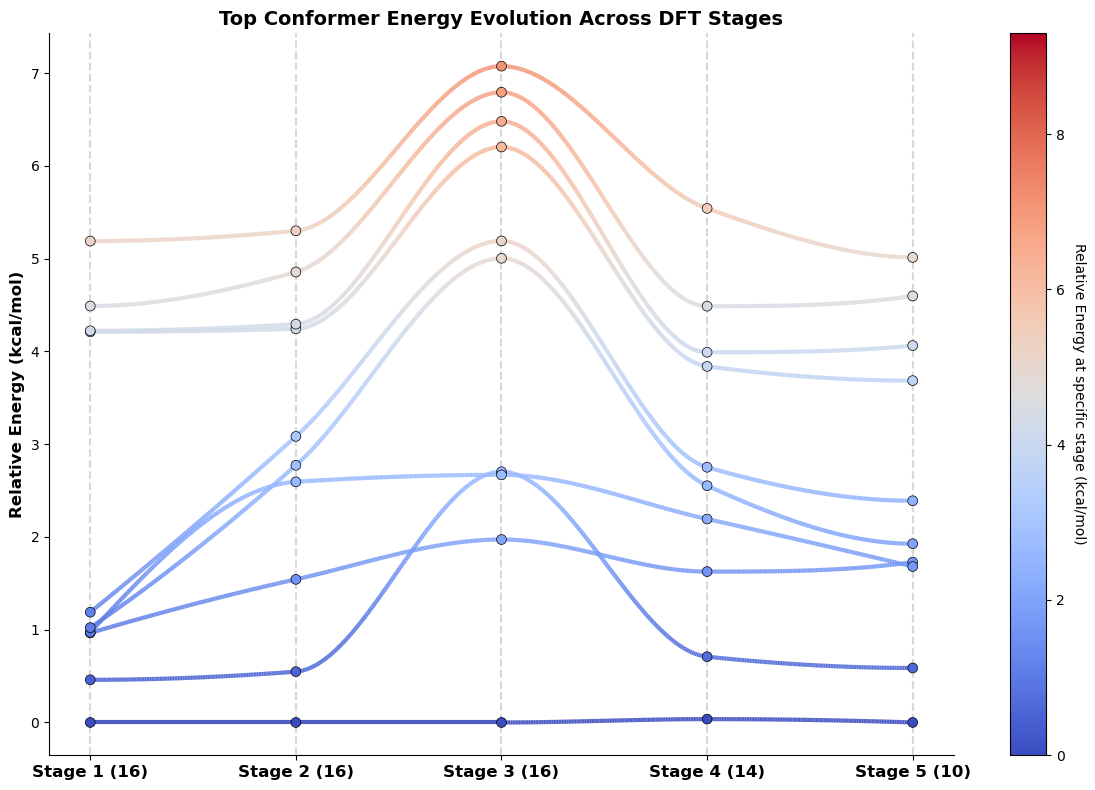

In [8]:
for structure in structures:
    plot_evolution(structure)

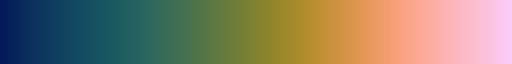

In [9]:
palette = cmc.batlow
palette

In [10]:
plt.style.use('../src/style_files/achemso.mplstyle')
df = pd.read_csv(f'{data_path}/{structure}.csv', index_col=0)
df.head()

,Stage 1,Stage 2,Stage 3,Stage 4,Stage 5
1,0.000000,0.000000,0.000000,0.036087,0.000000
2,0.459749,0.547851,2.702695,0.708772,0.587405
3,0.965361,1.542431,1.972053,1.626136,1.727969
4,0.970677,2.593767,2.668754,2.192863,1.680893
5,1.022375,2.771981,5.003182,2.551972,1.926696


6 conformers below 3.0 kcal/mol at Stage 5


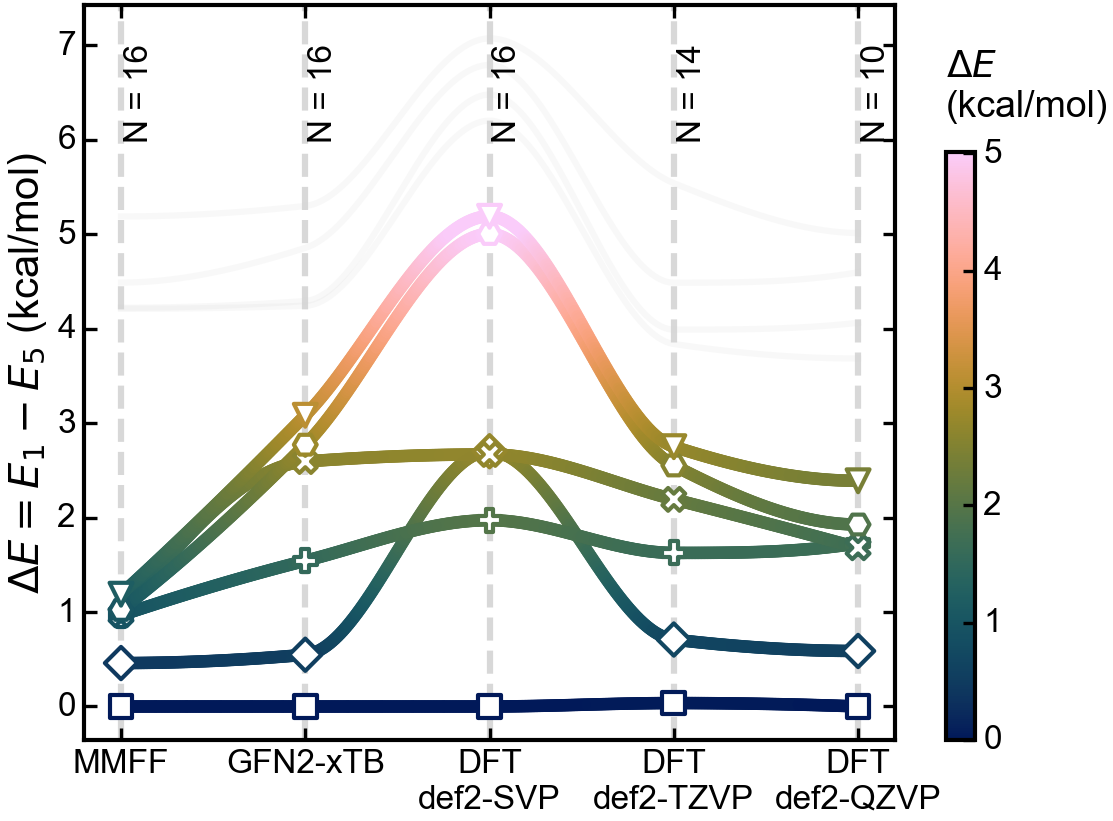

In [11]:

# 2. Define stages and setup X-axis coordinates
n_notNAN_each_stage = df.notna().sum(axis=0)
# print(n_notNAN_each_stage)
stages = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']
stage_labels = {stages[0]: 'MMFF', stages[1]: 'GFN2-xTB', stages[2]: 'DFT\ndef2-SVP', stages[3]: 'DFT\ndef2-TZVP', stages[4]: 'DFT\ndef2-QZVP'}
x_orig = np.arange(1, len(stages) + 1)  # [1, 2, 3, 4, 5]
x_smooth = np.linspace(x_orig.min(), x_orig.max(), 500)

fig, ax = plt.subplots(figsize=(4,3))

# 3. Define a GLOBAL Color Gradient
# To show color changes accurately across stages, we need the min/max of ALL stages, 
# not just Stage 5.
# all_energies = df[stages].values.flatten()
# finite_energies = all_energies[np.isfinite(all_energies)]

# if len(finite_energies) > 0:
#     norm = Normalize(vmin=finite_energies.min(), vmax=finite_energies.max())
# else:
#     norm = Normalize(vmin=0, vmax=1)

# try:
#     cmap = plt.colormaps['coolwarm']
# except AttributeError:
#     cmap = plt.get_cmap('coolwarm')

# In step 3, replace the all_energies norm with:
stage5_energies = df['Stage 5'].dropna().values
norm = Normalize(vmin=stage5_energies.min(), vmax=stage5_energies.max())

# 4. Find the top n conformers
#top_n = 20
# df_sorted = df.sort_values(by='Stage 5')
# top_conformers = df_sorted.head(top_n).index

# 4. Find conformers below energy threshold at Stage 5
threshold = 3.0  # kcal/mol — adjust to taste
top_conformers = df[df['Stage 5'] < threshold].index
markers = ['o', 's', 'D', 'P', 'X', 'H', 'v', '^', '<', '>', 'p', '*', 'h', '8', '1']
print(f"{len(top_conformers)} conformers below {threshold} kcal/mol at Stage 5")

# 5. Plot each conformer's evolution
for index, row in df.iterrows():
    y_orig = row[stages].values.astype(float)
    if not np.all(np.isfinite(y_orig)): continue

    interpolator = PchipInterpolator(x_orig, y_orig)
    y_smooth = interpolator(x_smooth)

    if index in top_conformers:
        # Highlight it with a continuous gradient using LineCollection
        # We chop the line into tiny (x,y) to (x+1, y+1) segments
        points = np.array([x_smooth, y_smooth]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        # Create the collection of segments
        lc = LineCollection(
            segments, cmap=palette, norm=norm,
            capstyle='round', joinstyle='round'
        )
        # Set the color of each segment based on its specific y_smooth value
        lc.set_array(y_smooth[:-1])
        lc.set_linewidth(3)
        lc.set_alpha(0.9)
        lc.set_zorder(4)

        ax.add_collection(lc) # Add the gradient line to the plot
        
        # Plot the actual data points at each stage, colored by their specific energy
        scatter_colors = palette(norm(y_orig))
        ax.scatter(x_orig, y_orig, color='white', s=30, zorder=5, edgecolor=scatter_colors, marker=markers[index])
        
    else:
        # Background it! Make it faint grey
        ax.plot(x_smooth, y_smooth, color='lightgray', alpha=0.15, zorder=2)

# 6. Styling the Graph
for i, x in enumerate(x_orig):
    ax.axvline(x, color='gray', linestyle='--', alpha=0.3, zorder=1)
    text = f"N = {n_notNAN_each_stage.iloc[i]}"
    ax.text(x+0.1, 6.5, text, fontsize=8, rotation= 90, ha='center', va='center')

ax.set_xticks(x_orig)
#ax.set_xlabel('DFT Level')
ax.set_xticklabels([f"{stage_labels[stage]}" for i, stage in enumerate(stages)], ha='center')
ax.set_ylabel(r'$\Delta E = E_1 - E_5$ (kcal/mol)')
#ax.set_title('Top Conformer Energy Evolution Across DFT Stages', fontsize=14, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])

# Show the colorbar. Place it to the right of the main axis.
cbar = fig.colorbar(
    sm, ax=ax, orientation='vertical', shrink=0.8,
    anchor=(0.0, 0.0),  # Align bottom of cbar with bottom of x-axis
    location='right',   # Still place on right
    pad=0.05
)
# For the colorbar label, it should be a single string, not an array.
colorbar_label = r'$\Delta E$' + '\n' + r'(kcal/mol)'
cbar.set_label(colorbar_label, fontsize=9, rotation=0, ha='left')

cbar.ax.yaxis.set_label_position('left')
cbar.ax.yaxis.set_label_coords(.0, 1.05)  # move to top, outside colorbar


plt.tight_layout()
plt.show()